In [1]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


The goal of this project is to predict which customers are likely to respond to a marketing campaign, allowing the company to reduce marketing costs and improve conversion rates.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from datetime import datetime
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
path = "/content/drive/MyDrive/Data Analysis Portfolio/"
File = "Market Campaign Analysis/marketing_campaign.csv"

In [32]:
#https://www.kaggle.com/datasets/rodsaldanha/arketing-campaign/data
data = pd.read_csv(path+File, sep=';' )
# from google.colab import sheets
# sheet = sheets.InteractiveSheet(df=data)

In [33]:
data.tail(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,2012-10-15,40,84,...,7,0,0,0,0,0,0,3,11,1


### Data Preprocessing:


In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [35]:
data['Income'].isnull().sum()

np.int64(24)

In [36]:
##Income likely depends on Education or Marital_Status. You can impute by group median.

data['Income'] = data.groupby(['Education', 'Marital_Status'])['Income'] \
                  .transform(lambda x: x.fillna(x.median()))
data['Income'].isnull().sum()

np.int64(0)

###Feature Engineering


In [37]:
#Variable Age in replacement of the variable Year_birth
current_year = datetime.now().year
data['Age'] = current_year - data['Year_Birth']

#drop Year_Birth, we  don’t need it:
data.drop(columns=['Year_Birth'], inplace=True)

In [38]:
## Variable Spending as the sum of the amount spent on the 6 product categories

data['Spending'] = (
    data['MntWines'] +
    data['MntFruits'] +
    data['MntMeatProducts'] +
    data['MntFishProducts'] +
    data['MntSweetProducts'] +
    data['MntGoldProds']
)




In [39]:
##Marital_Situation — grouping into “In couple” vs “Alone”
print(data['Marital_Status'].unique())

data['Marital_Situation'] = data['Marital_Status'].replace({
    'Married': 'In_couple',
    'Together': 'In_couple',
    'Single': 'Alone',
    'Divorced': 'Alone',
    'Widow': 'Alone',
    'Alone': 'Alone',
    'YOLO': 'Alone',
    'Absurd': 'Alone'
})

#drop marital status, no lonhger needed
data.drop(columns=['Marital_Status'], inplace=True)

data['Marital_Situation'].unique()

['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


array(['Alone', 'In_couple'], dtype=object)

In [40]:
#combine the variables  kidhome and teenhome into just one variable 'Has_child

data['No_children'] = ((data['Kidhome'] + data['Teenhome']) > 0).astype(int)

#or Y/N instead on int
#data['Has_child'] = ((data['Kidhome'] + data['Teenhome']) > 0).astype(int)

data.drop(columns='Kidhome' , inplace=True)
data.drop(columns='Teenhome' , inplace=True)

In [41]:
data['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [42]:
#replace Graduations, 2nd Cycle with common names i.e Undergrad, HighSchool
data['Education'] = data['Education'].replace({
    'Graduation': 'Undergrad',
    '2n Cycle': 'HighSchool'})

In [43]:
#map the education to number of years studied instead
education_years_map = {
    'Basic': 9,
    'HighSchool': 12,
    'Undergrad': 16,
    'Master': 18,
    'PhD': 21
}

data['Educational_years'] = data['Education'].map(education_years_map)

data.drop(columns=['Education'], inplace=True)

In [44]:
#not useful for the analysis features
data.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue','Dt_Customer','Marital_Situation'], inplace=True)

In [45]:
### Statitical Summary
data.describe()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spending,No_children,Educational_years
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52231.860714,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,...,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107,57.194196,605.798214,0.715179,16.883929
std,25039.866195,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,...,0.262728,0.259813,0.245316,0.114976,0.096391,0.356274,11.984069,602.249288,0.451430,2.817496
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,5.000000,0.000000,9.000000
25%,35538.750000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,49.000000,68.750000,0.000000,16.000000
50%,51222.500000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,396.000000,1.000000,16.000000
75%,68289.750000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000,1045.500000,1.000000,18.000000
max,666666.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,133.000000,2525.000000,1.000000,21.000000


## Model Training

In [46]:
X = data.drop(columns=['Response'])
y = data['Response']
y.T.value_counts()

,count
Response,
0,1906
1,334


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(1792, 23)
(448, 23)
Response
0    1525
1     267
Name: count, dtype: int64
Response
0    381
1     67
Name: count, dtype: int64


In [48]:
#since the data is imbalanced

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f' before SMOTE: {y_train.value_counts()}')

print(f' After SMOTE: {y_resampled.value_counts()}')

 before SMOTE: Response
0    1525
1     267
Name: count, dtype: int64
 After SMOTE: Response
0    1525
1    1525
Name: count, dtype: int64




<p style="font-size: 76px;"> Evaluating multiple models to identify the best approach for predicting customer response.</p>




In [49]:
#CatBoost Classifier
catb_model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6, verbose=0)
catb_model.fit(X_resampled, y_resampled)
y_pred_cat = catb_model.predict(X_test)

# Random Forest Classifier
randf_model = RandomForestClassifier(n_estimators=100, random_state=42)
randf_model.fit(X_resampled, y_resampled)
y_pred_rf = randf_model.predict(X_test)

# XGBoost Classifier
xboost_model = XGBClassifier(n_estimators=100, random_state=42)
xboost_model.fit(X_resampled, y_resampled)
y_pred_xgb = xboost_model.predict(X_test)

# LightGBM Classifier
lgbm_model = LGBMClassifier(Verbose = 0)
lgbm_model.fit(X_resampled, y_resampled)
y_pred_lgbm = lgbm_model.predict(X_test)

# K-Nearest Neighbors Classifier
kn_model = KNeighborsClassifier(n_neighbors=3)
kn_model.fit(X_resampled, y_resampled)
y_pred_knn = kn_model.predict(X_test)

# AdaBoost Classifier
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_resampled, y_resampled)
y_pred_ada = ada_model.predict(X_test)

[LightGBM] [Warning] Unknown parameter: Verbose
[LightGBM] [Warning] Unknown parameter: Verbose
[LightGBM] [Info] Number of positive: 1525, number of negative: 1525
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1965
[LightGBM] [Info] Number of data points in the train set: 3050, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Unknown parameter: Verbose


In [50]:
print('CatBoost F1:', f1_score(y_test, y_pred_cat))
print('CatBoost Accuracy Score:', accuracy_score(y_test, y_pred_cat))
print('----------------------------')
print('Random Forest F1:', f1_score(y_test, y_pred_rf))
print('Random Forest Accuracy Score:', accuracy_score(y_test, y_pred_rf))
print('----------------------------')
print('XGBoost F1:', f1_score(y_test, y_pred_xgb))
print('XGBoost Accuracy Score:', accuracy_score(y_test, y_pred_xgb))
print('----------------------------')
print('LightGBM F1:', f1_score(y_test, y_pred_lgbm))
print('LightGBM Accuracy Score:', accuracy_score(y_test, y_pred_lgbm))
print('----------------------------')
print('K-Nearest Neighbors F1:', f1_score(y_test, y_pred_knn))
print('K-Nearest Neighbors Accuracy Score:', accuracy_score(y_test, y_pred_knn))
print('----------------------------')
print('AdaBoost F1:', f1_score(y_test, y_pred_ada))
print('AdaBoost Accuracy Score:', accuracy_score(y_test, y_pred_ada))

CatBoost F1: 0.5161290322580645
CatBoost Accuracy Score: 0.8660714285714286
----------------------------
Random Forest F1: 0.48175182481751827
Random Forest Accuracy Score: 0.8415178571428571
----------------------------
XGBoost F1: 0.4881889763779528
XGBoost Accuracy Score: 0.8549107142857143
----------------------------
LightGBM F1: 0.5
LightGBM Accuracy Score: 0.8571428571428571
----------------------------
K-Nearest Neighbors F1: 0.36633663366336633
K-Nearest Neighbors Accuracy Score: 0.7142857142857143
----------------------------
AdaBoost F1: 0.48
AdaBoost Accuracy Score: 0.796875


In [51]:
models = ['CatBoost', 'Random Forest', 'XGBoost', 'LightGBM', 'KNN', 'AdaBoost']

accuracy_scores = [
    accuracy_score(y_test, y_pred_cat),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_lgbm),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_ada)
]

f1_scores = [
    f1_score(y_test, y_pred_cat),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xgb),
    f1_score(y_test, y_pred_lgbm),
    f1_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_ada)
]

In [25]:
import plotly.graph_objects as go

fig = go.Figure()

# Accuracy bars
fig.add_trace(go.Bar(
    x=models,
    y=accuracy_scores,
    name='Accuracy'
))

# F1 bars
fig.add_trace(go.Bar(
    x=models,
    y=f1_scores,
    name='F1 Score'
))

# Layout for clustering
fig.update_layout(
    title='Model Performance Comparison',
    xaxis_title='Models',
    yaxis_title='Score',
    barmode='group',  # clustered
    template='plotly_white'
)

fig.update_traces(texttemplate='%{y:.3f}', textposition='outside')

fig.show()

While most models achieve high accuracy due to class imbalance, F1 score provides a better evaluation metric. CatBoost outperforms other models by achieving the highest F1 score, making it the most suitable model for predicting customer response.

The model is able to correctly identify a significant portion of responsive customers, which can help reduce wasted marketing spend.

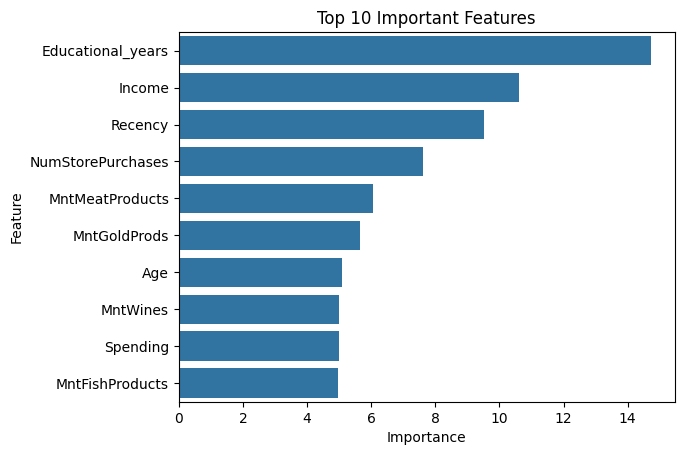

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

feature_importance = catb_model.get_feature_importance()
features = X.columns

feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

sn.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

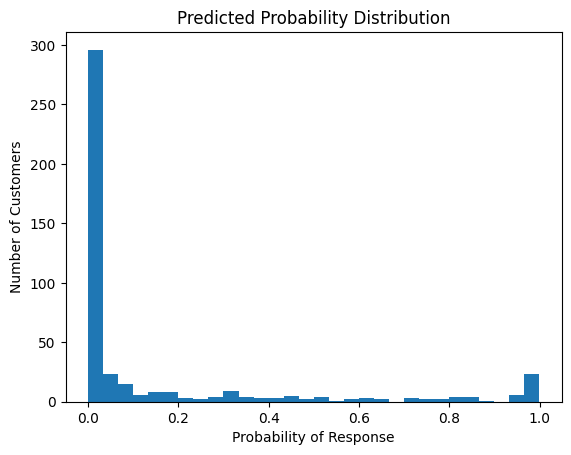

In [27]:

y_proba = catb_model.predict_proba(X_test)[:,1]

plt.hist(y_proba, bins=30)
plt.title("Predicted Probability Distribution")
plt.xlabel("Probability of Response")
plt.ylabel("Number of Customers")
plt.show()


* Most customers are near 0 probability
* A small group is near high probability (0.8–1.0)


In [28]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Probability": y_proba
})

results = results.sort_values(by="Probability", ascending=False)

# Top 20%
top_20 = int(len(results) * 0.2)
top_customers = results.head(top_20)

response_rate = top_customers["Actual"].mean()

print("Response rate in top 20%:", response_rate)

Response rate in top 20%: 0.4157303370786517


overall response rate

* Total customers = **2240**
* Responders (Response = 1) = **334**

So:


$\text{Response Rate} = \frac{334}{2240} \approx 0.149 \approx 15\%$


Model-driven targeting: $41.6\%$. This is $2.8 \times $ improvement

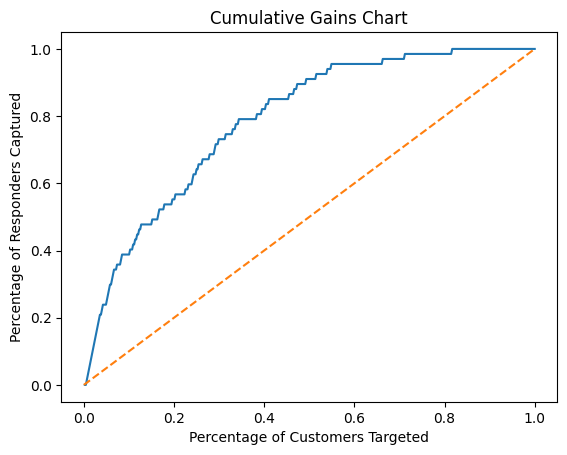

In [29]:
#Cmunulative Gains chart

results['cumulative_responders'] = results['Actual'].cumsum()
results['cumulative_percentage'] = results['cumulative_responders'] / results['Actual'].sum()

results['population_percentage'] = range(1, len(results)+1)
results['population_percentage'] = results['population_percentage'] / len(results)

plt.plot(results['population_percentage'], results['cumulative_percentage'])
plt.plot([0,1], [0,1], linestyle='--')  # baseline
plt.title("Cumulative Gains Chart")
plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Percentage of Responders Captured")
plt.show()

The cumulative gains chart shows that the model effectively ranks customers by their likelihood to respond.

By targeting only the top 20% of customers, the company can capture approximately 40–50% of all potential responders.

This is significantly better than random targeting, where 20% of customers would yield only 20% of responders.

The steep initial slope indicates that the model successfully identifies high-value customers early, while the flattening of the curve suggests diminishing returns when targeting larger portions of the population.


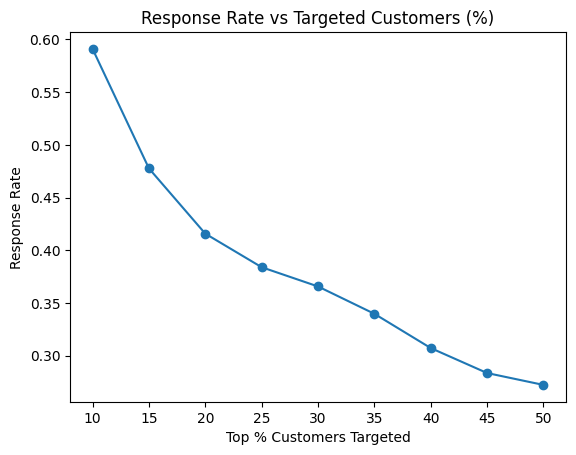

In [30]:
top_percents = []
response_rates = []

for p in range(10, 51, 5):
    top_n = int(len(results) * (p/100))
    rate = results.head(top_n)["Actual"].mean()

    top_percents.append(p)
    response_rates.append(rate)

plt.plot(top_percents, response_rates, marker='o')
plt.title("Response Rate vs Targeted Customers (%)")
plt.xlabel("Top % Customers Targeted")
plt.ylabel("Response Rate")
plt.show()

For hight returns, target around 20% of the customers

#In conclusion

By leveraging this model, the company can:

Reduce marketing costs by avoiding low-value customers
Increase campaign efficiency by focusing on high-probability responders
Maximize ROI through data-driven targeting

Instead of sending campaigns to all customers, targeting a small, high-value segment can yield significantly higher returns with lower cost